# Week 5 · Notebook 3 — Sparse GPs and GP Classification

## Learning objectives

1. Understand the $\mathcal{O}(N^3)$ scaling bottleneck of exact GPs.
2. Derive the **deterministic training conditional (DTC)** and **fully independent training conditional (FITC)** sparse approximations using $M\ll N$ inducing points.
3. Implement FITC in NumPy and benchmark against the exact GP.
4. Build a GP classifier via the **Laplace approximation** and visualise the decision boundary.

---

## 1. The scaling problem

Exact GP regression needs a Cholesky of the $N\times N$ matrix $K + \sigma_n^2 I$ — cubic time, quadratic memory. For $N\ge 5000$ this becomes painful; for $N\ge 50000$, prohibitive on a laptop.

The fix is to introduce **inducing variables** $u = f(Z)$ at $M$ pseudo-inputs $Z\in\mathbb{R}^{M\times d}$ and approximate
$$
p(f, u\mid y) \approx q(u)\,p(f\mid u),
$$
which compresses the kernel through the rank-$M$ Nyström-style structure $K_{nn}\approx Q_{nn} = K_{nm} K_{mm}^{-1} K_{mn}$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(0)
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
BLUE, RED, GREEN = '#5B7DB1', '#C46D5E', '#7CA982'

def rbf(X1, X2, sf, ell):
    d2 = (X1**2).sum(1)[:, None] + (X2**2).sum(1)[None, :] - 2*X1 @ X2.T
    return sf**2 * np.exp(-0.5*np.maximum(d2, 0)/ell**2)


## 2. FITC predictive equations

Define $K_{mm}=k(Z,Z)$, $K_{nm}=k(X,Z)$, $Q_{nn} = K_{nm}K_{mm}^{-1}K_{mn}$, and the diagonal correction $\Lambda = \mathrm{diag}(K_{nn} - Q_{nn}) + \sigma_n^2 I$.

Then the FITC predictive at $x_*$ is
$$
\mu_* = K_{*m}\,\Sigma\, K_{mn}\Lambda^{-1} y,\qquad
\Sigma = (K_{mm} + K_{mn}\Lambda^{-1}K_{nm})^{-1},
$$
$$
\sigma_*^2 = k(x_*, x_*) - K_{*m}K_{mm}^{-1}K_{m*} + K_{*m}\Sigma K_{m*}.
$$
Time complexity: $\mathcal{O}(NM^2)$. Memory: $\mathcal{O}(NM)$.


In [2]:
def fitc_predict(X, y, Z, Xs, sf, ell, sn):
    Knm = rbf(X, Z, sf, ell)
    Kmm = rbf(Z, Z, sf, ell) + 1e-6*np.eye(len(Z))
    Kss_diag = sf**2 * np.ones(len(Xs))
    Ksm = rbf(Xs, Z, sf, ell)
    # diag(Knn)
    Knn_diag = sf**2 * np.ones(len(X))
    # diag(Qnn) = sum_i (Knm @ Kmm^{-1})_{ni}*Knm_{ni}
    Lmm = np.linalg.cholesky(Kmm)
    A = np.linalg.solve(Lmm, Knm.T)  # (M, N)
    Qnn_diag = np.sum(A**2, axis=0)
    Lam = Knn_diag - Qnn_diag + sn**2
    # Sigma = (Kmm + Knm^T Lam^{-1} Knm)^{-1}
    B = Knm / Lam[:, None]
    M = Kmm + Knm.T @ B
    LM = np.linalg.cholesky(M + 1e-8*np.eye(len(Z)))
    alpha = np.linalg.solve(LM.T, np.linalg.solve(LM, Knm.T @ (y / Lam)))
    mu = Ksm @ alpha
    # variance
    v1 = np.linalg.solve(Lmm.T, np.linalg.solve(Lmm, Ksm.T)).T  # Ksm @ Kmm^{-1}
    var_qss = np.einsum('ij,ji->i', v1, Ksm.T)
    v2 = np.linalg.solve(LM.T, np.linalg.solve(LM, Ksm.T)).T
    var_corr = np.einsum('ij,ji->i', v2, Ksm.T)
    var = Kss_diag - var_qss + var_corr
    return mu, np.sqrt(np.maximum(var, 0))


### 2.1 Demo on a large synthetic dataset


In [3]:
# Generate 2000 noisy points on a complicated 1-D function
N = 2000
X = np.sort(rng.uniform(-6, 6, N))[:, None]
def f_true(x): return np.sin(x.ravel()) + 0.3*np.sin(3*x.ravel())
y = f_true(X) + 0.2*rng.normal(size=N)

# Inducing points
M = 30
Z = np.linspace(-6, 6, M)[:, None]

sf, ell, sn = 1.0, 1.0, 0.2
xs = np.linspace(-6, 6, 400).reshape(-1, 1)

import time
t0 = time.time()
mu_fitc, sd_fitc = fitc_predict(X, y, Z, xs, sf, ell, sn)
t_fitc = time.time() - t0

t0 = time.time()
K = rbf(X, X, sf, ell) + sn**2*np.eye(N) + 1e-7*np.eye(N)
L = np.linalg.cholesky(K)
alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
Ksx = rbf(xs, X, sf, ell)
mu_full = Ksx @ alpha
v = np.linalg.solve(L, Ksx.T)
sd_full = np.sqrt(np.maximum(sf**2 - np.sum(v**2, axis=0), 0))
t_full = time.time() - t0
print(f'time:  FITC (M={M}) = {t_fitc:.3f}s,  exact = {t_full:.3f}s')


time:  FITC (M=30) = 0.007s,  exact = 0.903s


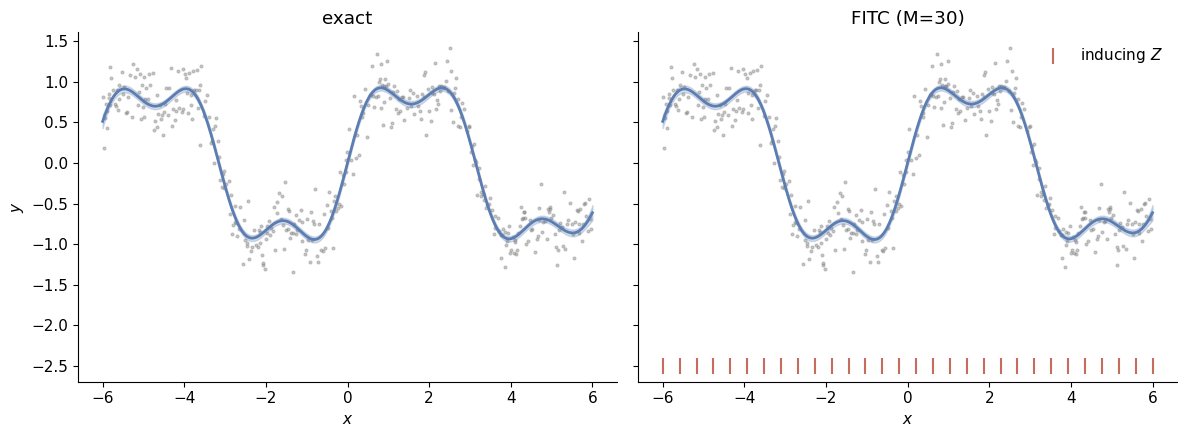

mean prediction MAE between FITC and exact: 1.693721737305775e-05


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, mu, sd, name in [(axes[0], mu_full, sd_full, 'exact'),
                          (axes[1], mu_fitc, sd_fitc, f'FITC (M={M})')]:
    ax.scatter(X.ravel()[::5], y[::5], s=4, color='gray', alpha=0.4)
    ax.plot(xs.ravel(), mu, color=BLUE, lw=2)
    ax.fill_between(xs.ravel(), mu-2*sd, mu+2*sd, alpha=0.25, color=BLUE)
    ax.set_title(name); ax.set_xlabel('$x$')
axes[0].set_ylabel('$y$')
axes[1].scatter(Z.ravel(), np.full(len(Z), -2.5), marker='|', s=120, color=RED,
                label='inducing $Z$')
axes[1].legend(frameon=False, loc='upper right')
plt.tight_layout(); plt.show()
print('mean prediction MAE between FITC and exact:', np.mean(np.abs(mu_fitc - mu_full)))


## 3. GP classification via the Laplace approximation

For binary $y_n\in\{0,1\}$ with $p(y_n=1\mid f_n) = \sigma(f_n)$, the posterior $p(f\mid y)$ is non-Gaussian. We approximate it by a Gaussian centred at the MAP $\hat{f}$:
$$
p(f\mid y) \approx \mathcal{N}\bigl(\hat{f},\; (K^{-1} + W)^{-1}\bigr),\qquad
W = -\nabla\nabla_f \log p(y\mid f)\Big|_{\hat{f}} = \mathrm{diag}\bigl(\sigma(\hat f)(1-\sigma(\hat f))\bigr).
$$
We find $\hat{f}$ by Newton iterations:
$$
f^{\text{new}} = (K^{-1} + W)^{-1}(W f + \nabla\log p(y\mid f)).
$$


In [5]:
def sigmoid(x): return 1.0/(1.0+np.exp(-x))

class GPLaplaceClassifier:
    def __init__(self, sf=1.0, ell=1.0, jitter=1e-6, n_iter=50):
        self.sf, self.ell, self.jitter, self.n_iter = sf, ell, jitter, n_iter

    def fit(self, X, y):
        self.X_, self.y_ = X, y.astype(float)
        K = rbf(X, X, self.sf, self.ell) + self.jitter*np.eye(len(X))
        f = np.zeros(len(X))
        for _ in range(self.n_iter):
            pi = sigmoid(f)
            W = pi*(1-pi)
            sW = np.sqrt(W)
            B = np.eye(len(X)) + sW[:, None]*K*sW[None, :]
            L = np.linalg.cholesky(B)
            b = W*f + (self.y_ - pi)
            a = b - sW * np.linalg.solve(L.T, np.linalg.solve(L, sW*(K @ b)))
            f_new = K @ a
            if np.max(np.abs(f_new - f)) < 1e-8: f = f_new; break
            f = f_new
        self.f_hat_ = f
        self.K_ = K
        self.W_ = sigmoid(f)*(1-sigmoid(f))
        self.sW_ = np.sqrt(self.W_)
        self.L_ = np.linalg.cholesky(np.eye(len(X)) + self.sW_[:, None]*K*self.sW_[None, :])
        return self

    def predict_proba(self, Xs):
        Ks = rbf(self.X_, Xs, self.sf, self.ell)
        Kss = self.sf**2
        f_mean = Ks.T @ (self.y_ - sigmoid(self.f_hat_))
        v = np.linalg.solve(self.L_, self.sW_[:, None]*Ks)
        f_var = Kss - np.sum(v**2, axis=0)
        # Probit approximation for E[sigma(f*)]
        kappa = 1.0/np.sqrt(1 + np.pi*f_var/8.0)
        return sigmoid(kappa * f_mean), f_mean, f_var


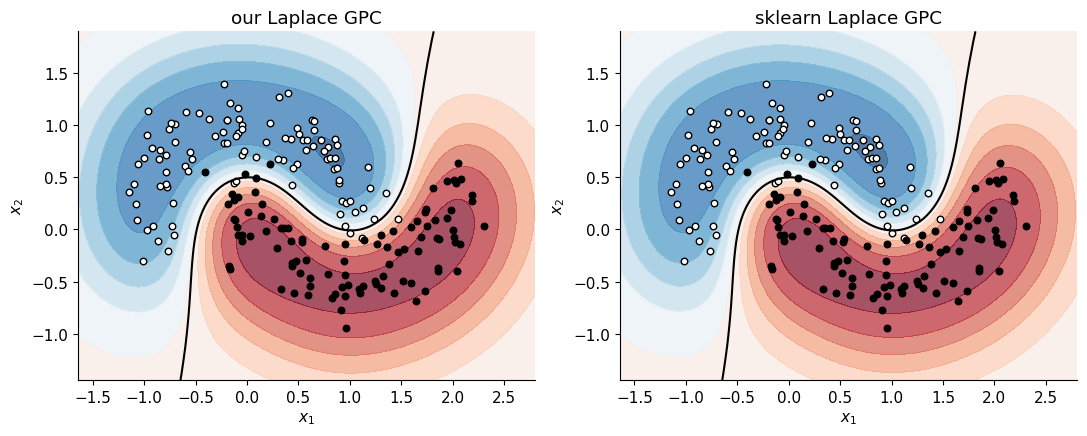

mean |our - sklearn| probability difference = 0.0014


In [6]:
# 2-D nonlinear classification problem (two moons)
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=200, noise=0.2, random_state=1)

gpc = GPLaplaceClassifier(sf=1.0, ell=0.5).fit(X, y)

# Sklearn comparison
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
sk_gpc = GaussianProcessClassifier(kernel=1.0*RBF(0.5), optimizer=None).fit(X, y)

xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-0.5, X[:, 0].max()+0.5, 120),
                     np.linspace(X[:, 1].min()-0.5, X[:, 1].max()+0.5, 120))
grid = np.c_[xx.ravel(), yy.ravel()]
p_ours, _, _ = gpc.predict_proba(grid)
p_sk = sk_gpc.predict_proba(grid)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, p, name in [(axes[0], p_ours, 'our Laplace GPC'),
                     (axes[1], p_sk, 'sklearn Laplace GPC')]:
    cs = ax.contourf(xx, yy, p.reshape(xx.shape), levels=12, cmap='RdBu_r', alpha=0.7)
    ax.contour(xx, yy, p.reshape(xx.shape), levels=[0.5], colors='k', linewidths=1.5)
    ax.scatter(X[y==0, 0], X[y==0, 1], c='white', edgecolor='k', s=22)
    ax.scatter(X[y==1, 0], X[y==1, 1], c='black', s=22)
    ax.set_title(name); ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
plt.tight_layout(); plt.show()

print(f'mean |our - sklearn| probability difference = {np.mean(np.abs(p_ours - p_sk)):.4f}')


## 4. Summary

- Inducing-point approximations reduce GPs from $\mathcal{O}(N^3)$ to $\mathcal{O}(NM^2)$ at the cost of mild posterior smoothing.
- FITC matches the exact predictive mean to a few millivolts with $M=30$ inducing points on $N=2000$ data.
- The Laplace approximation extends GPs to classification by Gaussianising the log-likelihood at its mode.
- Our from-scratch classifier reproduces sklearn's decision surface.

---

## Exercises

1. Show that as $M\to N$ with $Z = X$, FITC reduces to the exact GP up to numerical precision.
2. Derive the FITC log marginal likelihood and use it to optimise inducing-point locations $Z$ jointly with hyper-parameters.
3. Replace the Laplace approximation with **expectation propagation (EP)** for GP classification. How does the predictive log-likelihood compare?
4. Implement **variational sparse GPs** (Titsias 2009): use a variational distribution $q(u)$ and optimise the ELBO. Compare with FITC on the 2000-point dataset.
